# Visualizations

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

full_df = pd.read_csv("newborn_health_monitoring_with_risk.csv")

# Only considering birth/final weights/lengths for now, so
df = full_df[full_df["age_days"]==30]
df

,baby_id,name,gender,gestational_age_weeks,birth_weight_kg,birth_length_cm,birth_head_circumference_cm,date,age_days,weight_kg,...,oxygen_saturation,feeding_type,feeding_frequency_per_day,urine_output_count,stool_count,jaundice_level_mg_dl,apgar_score,immunizations_done,reflexes_normal,risk_level
29,B001,Sara,Female,40.2,3.30,50.0,31.9,2025-01-08,30,4.26,...,97,Mixed,7,6,2,5.2,NaN,Yes,No,Healthy
59,B002,Nicole,Female,39.4,3.15,50.1,32.0,2025-08-26,30,4.05,...,97,Formula,10,9,0,2.1,NaN,Yes,No,Healthy
89,B003,James,Male,37.9,2.89,51.9,34.7,2024-11-15,30,3.82,...,98,Mixed,7,5,2,3.9,NaN,Yes,Yes,Healthy
119,B004,Donald,Male,38.2,2.87,53.3,34.4,2025-07-16,30,3.80,...,96,Mixed,12,5,0,2.7,NaN,Yes,Yes,Healthy
149,B005,Yvonne,Male,37.8,3.30,49.3,34.6,2025-02-11,30,4.15,...,98,Mixed,7,8,4,2.7,NaN,Yes,Yes,Healthy
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2879,B096,Vanessa,Female,38.9,2.83,49.7,35.5,2025-03-17,30,3.67,...,98,Mixed,10,4,2,1.7,NaN,Yes,Yes,Healthy
2909,B097,Jonathan,Female,38.5,3.00,54.4,33.1,2025-03-08,30,3.98,...,96,Formula,12,5,5,4.3,NaN,Yes,No,Healthy
2939,B098,Jennifer,Male,36.1,3.09,51.9,34.2,2024-12-23,30,3.99,...,97,Formula,8,6,2,2.2,NaN,Yes,Yes,Healthy
2969,B099,Terri,Female,38.5,3.81,46.5,32.8,2024-11-07,30,4.67,...,99,Breastfeeding,12,4,1,2.5,NaN,Yes,Yes,Healthy


## Weight/Length only

### Histograms

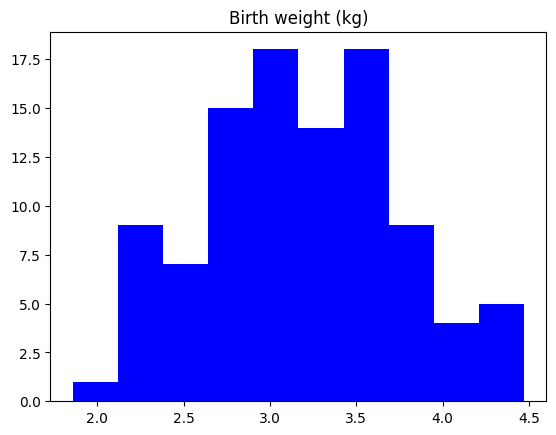

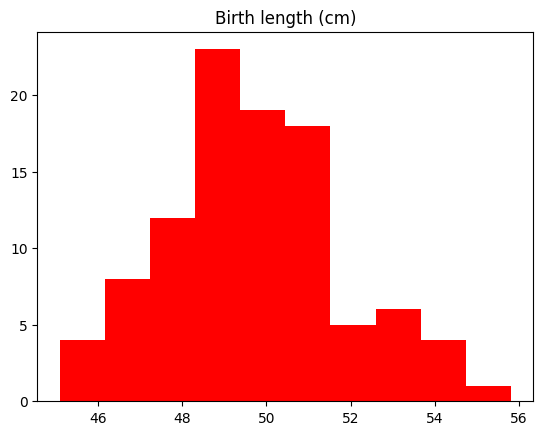

In [38]:
plt.title("Birth weight (kg)")
plt.hist(df["birth_weight_kg"], color="blue")
plt.show()

plt.title("Birth length (cm)")
plt.hist(df["birth_length_cm"], color="red")
plt.show()

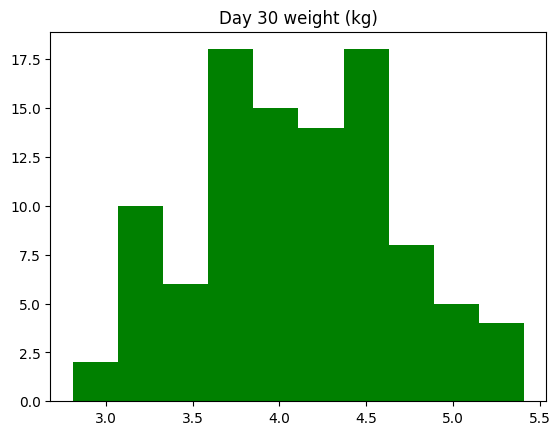

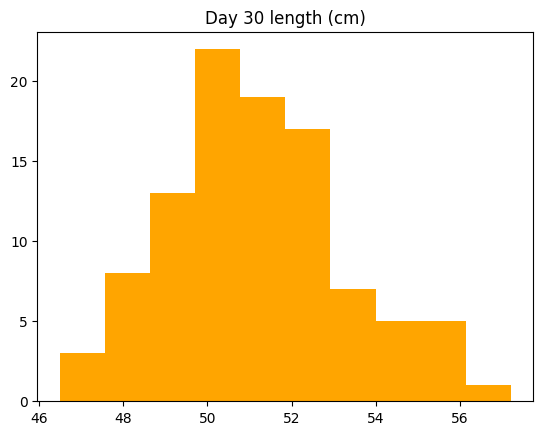

In [41]:
plt.title("Day 30 weight (kg)")
plt.hist(df["weight_kg"], color="green")
plt.show()

plt.title("Day 30 length (cm)")
plt.hist(df["length_cm"], color="orange")
plt.show()

### PP Plots

See Module 1 Lecture 2 Slide 17.

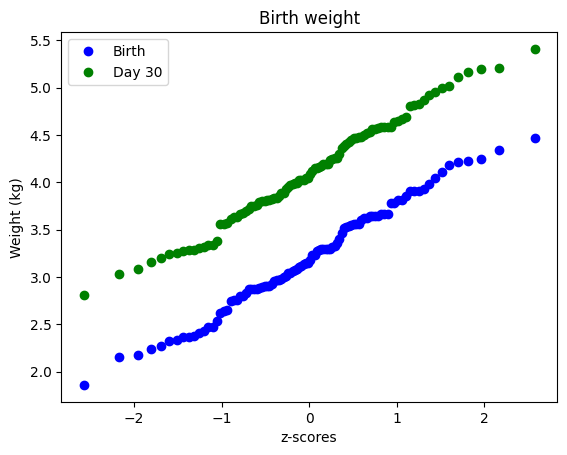

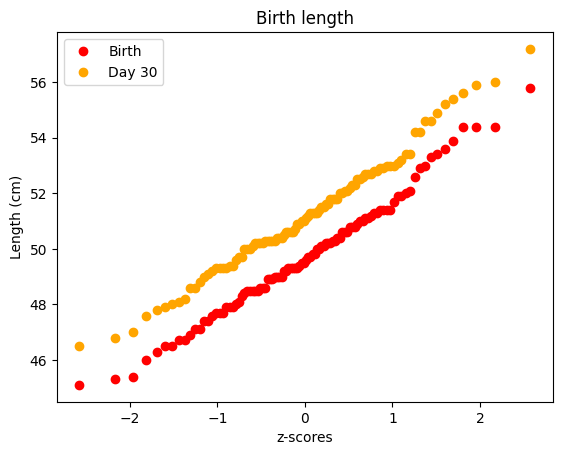

In [48]:
from scipy.stats import norm

sorted_birth_weights = np.sort(df["birth_weight_kg"])
sorted_birth_lengths = np.sort(df["birth_length_cm"])
sorted_day30_weights = np.sort(df["weight_kg"])
sorted_day30_lengths = np.sort(df["length_cm"])

n = len(sorted_birth_weights)
assert n == len(sorted_birth_lengths) and n == len(sorted_day30_weights) and n == len(sorted_day30_lengths)

# Step 1
quantiles = np.arange(0.5, n+0.5) / n
assert n == len(quantiles)

# Step 2
z_scores = norm.ppf(quantiles)

plt.title("Birth weight")
plt.plot(z_scores, sorted_birth_weights, "bo", label="Birth")
plt.plot(z_scores, sorted_day30_weights, "go", label="Day 30")
plt.xlabel("z-scores")
plt.ylabel("Weight (kg)")
plt.legend()
plt.show()

plt.title("Birth length")
plt.plot(z_scores, sorted_birth_lengths, "ro", label="Birth")
plt.plot(z_scores, sorted_day30_lengths, "o", color="orange", label="Day 30")
plt.xlabel("z-scores")
plt.ylabel("Length (cm)")
plt.legend()
plt.show()

The graphs appear linear; the samples seem to be approximately Normally distributed.

## Investigating Relationships

### Weight vs. Length

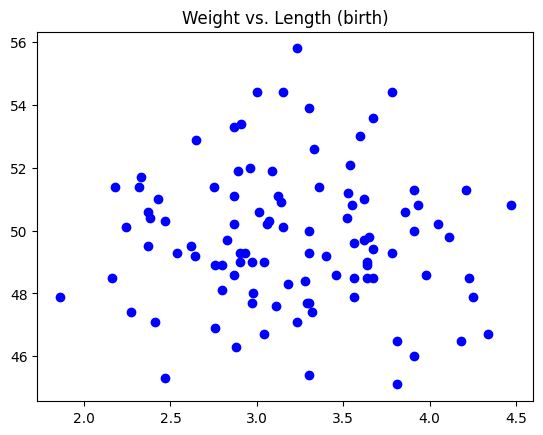

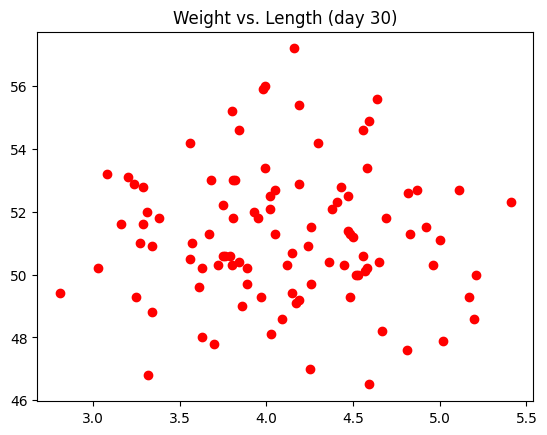

In [50]:
plt.title("Weight vs. Length (birth)")
plt.plot(df["birth_weight_kg"], df["birth_length_cm"], "bo")
plt.show()

plt.title("Weight vs. Length (day 30)")
plt.plot(df["weight_kg"], df["length_cm"], "ro")
plt.show()

Surprisingly, there doesn't seem to be much of a correlation between weight and length.

### Time

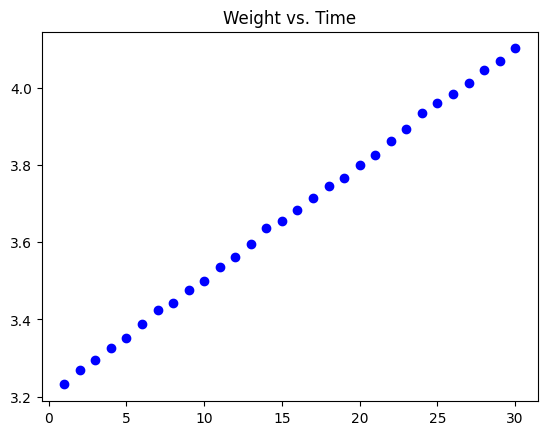

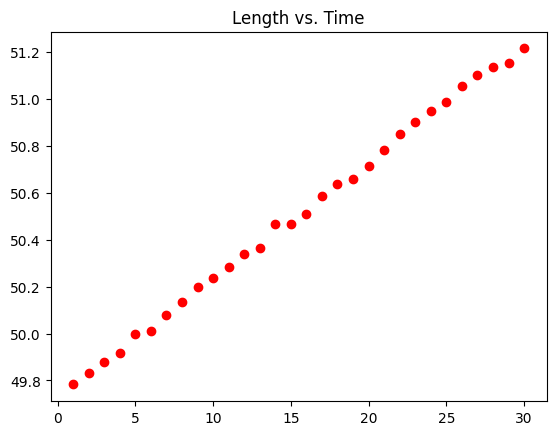

In [63]:
mean_weights = [np.mean(full_df[full_df["age_days"]==i]["weight_kg"]) for i in range(1, 31)]
mean_lengths = [np.mean(full_df[full_df["age_days"]==i]["length_cm"]) for i in range(1, 31)]

plt.title("Weight vs. Time")
plt.plot(range(1, 31), mean_weights, "bo")
plt.show()

plt.title("Length vs. Time")
plt.plot(range(1, 31), mean_lengths, "ro")
plt.show()

### Gender

In [51]:
df_male = df[df["gender"]=="Male"]
df_female = df[df["gender"]=="Female"]

df_female

,baby_id,name,gender,gestational_age_weeks,birth_weight_kg,birth_length_cm,birth_head_circumference_cm,date,age_days,weight_kg,...,oxygen_saturation,feeding_type,feeding_frequency_per_day,urine_output_count,stool_count,jaundice_level_mg_dl,apgar_score,immunizations_done,reflexes_normal,risk_level
29,B001,Sara,Female,40.2,3.30,50.0,31.9,2025-01-08,30,4.26,...,97,Mixed,7,6,2,5.2,NaN,Yes,No,Healthy
59,B002,Nicole,Female,39.4,3.15,50.1,32.0,2025-08-26,30,4.05,...,97,Formula,10,9,0,2.1,NaN,Yes,No,Healthy
209,B007,Michael,Female,39.9,3.62,51.0,35.2,2025-09-06,30,4.47,...,99,Formula,8,7,5,1.7,NaN,Yes,Yes,Healthy
269,B009,Christopher,Female,41.4,3.18,48.3,32.7,2025-07-24,30,4.12,...,97,Mixed,11,4,5,4.0,NaN,Yes,Yes,Healthy
329,B011,Mary,Female,37.0,2.18,51.4,38.1,2024-10-15,30,3.08,...,98,Mixed,11,9,3,4.0,NaN,Yes,Yes,Healthy
389,B013,Michael,Female,39.5,3.01,50.6,34.8,2025-05-12,30,4.02,...,98,Mixed,12,6,4,3.0,NaN,Yes,Yes,Healthy
479,B016,Stephen,Female,37.9,3.78,49.3,34.5,2025-03-11,30,4.65,...,96,Breastfeeding,12,6,5,3.6,NaN,Yes,Yes,Healthy
569,B019,Robin,Female,38.8,3.40,49.2,35.7,2025-03-15,30,4.24,...,97,Mixed,8,4,3,1.5,NaN,Yes,Yes,Healthy
629,B021,Jasmine,Female,38.9,2.16,48.5,33.9,2025-06-01,30,3.03,...,97,Mixed,12,5,5,3.8,NaN,Yes,Yes,Healthy
659,B022,Zachary,Female,39.7,2.88,46.3,37.5,2024-10-25,30,3.70,...,98,Breastfeeding,7,6,5,4.0,NaN,Yes,Yes,Healthy


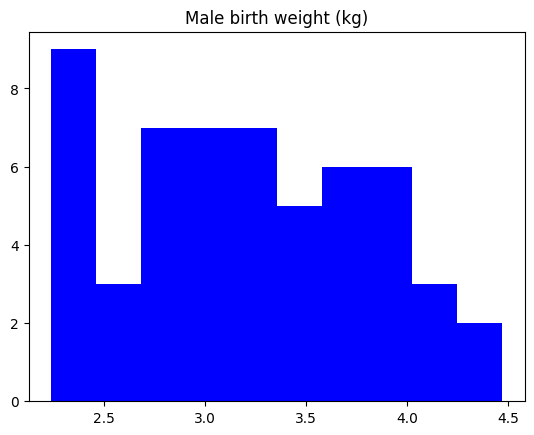

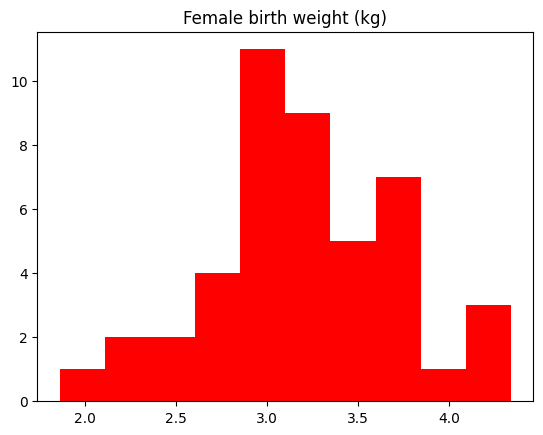

In [55]:
plt.title("Male birth weight (kg)")
plt.hist(df_male["birth_weight_kg"], color="blue")
plt.show()

plt.title("Female birth weight (kg)")
plt.hist(df_female["birth_weight_kg"], color="red")
plt.show()

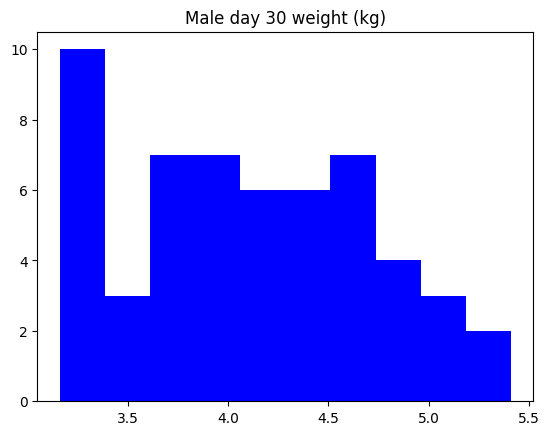

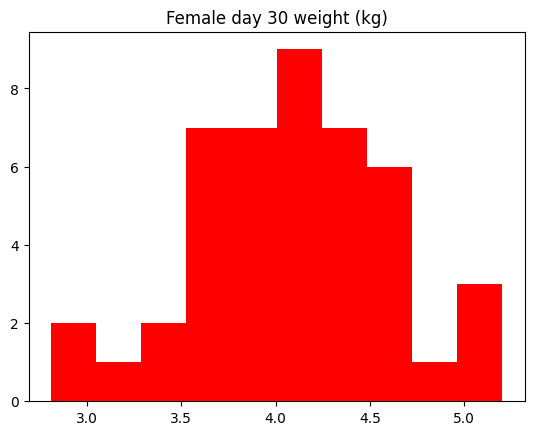

In [64]:
plt.title("Male day 30 weight (kg)")
plt.hist(df_male["weight_kg"], color="blue")
plt.show()

plt.title("Female day 30 weight (kg)")
plt.hist(df_female["weight_kg"], color="red")
plt.show()

# Hypothesis Testing

TODO: Hypothesis Testing